# TweetAge – Análisis descriptivo por grupo de edad
Objetivo: entender cómo escribe cada rango de edad antes de modelar, para justificar el preprocesamiento y las variables.
Unidad de análisis: **un tweet**. Métrica de la competencia: **F1 macro**.

In [5]:
import re, numpy as np, pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import kruskal
from sklearn.feature_extraction.text import CountVectorizer

TRAIN = r'C:\Users\leonk\Documents\MINTA 2025-01\PLN\age_train.csv'   # ajustar ruta
TEST  = r'C:\Users\leonk\Documents\MINTA 2025-01\PLN\age_test.csv'
ORDER = ['13-17','18-24','25-34','35-49','50-64','65-xx']

def load(path):
    # separador ';', BOM UTF-8, tweets con saltos de línea entre comillas, relleno de espacios a 140
    df = pd.read_csv(path, sep=';', encoding='utf-8-sig', dtype=str, keep_default_na=False)
    df['text'] = df['text'].str.strip()
    return df

tr, te = load(TRAIN), load(TEST)
print(tr.shape, te.shape)

(169336, 3) (112892, 2)


## 1. Distribución de clases

               n     %
age_range             
13-17      28863  17.0
18-24      28676  16.9
25-34      28347  16.7
35-49      28230  16.7
50-64      28060  16.6
65-xx      27160  16.0


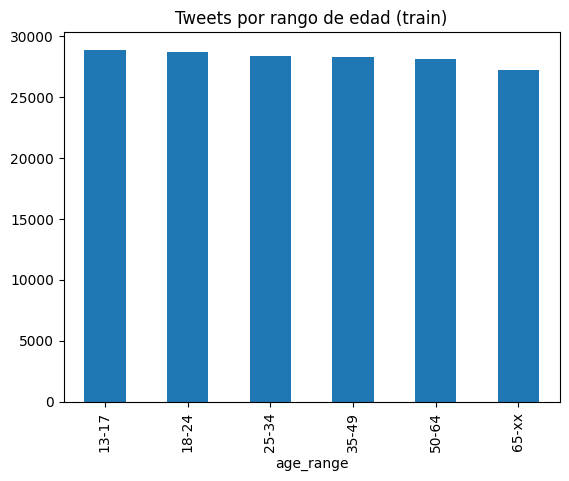

In [6]:
dist = tr.age_range.value_counts().reindex(ORDER)
print(pd.DataFrame({'n': dist, '%': (dist/len(tr)*100).round(1)}))
dist.plot.bar(title='Tweets por rango de edad (train)'); plt.show()

## 2. Calidad de datos: vacíos, duplicados, artefactos

In [7]:
nonempty = tr[tr.text.str.len() > 0]
g = nonempty.groupby('text')['age_range'].agg(n='size', k='nunique')
dup = g[g.n > 1]
print('Textos vacíos (train/test):', (tr.text=='').sum(), (te.text=='').sum())
print('Textos repetidos:', len(dup), '| filas:', dup.n.sum())
print('Textos repetidos con etiquetas distintas:', (dup.k > 1).sum(), '| filas:', dup.loc[dup.k>1,'n'].sum())
print('Artefacto de Excel "#¿NOMBRE?":', tr.text.str.contains(r'#¿NOMBRE').sum())
print('Entidades HTML (&lt; &gt; &amp;):', tr.text.str.contains(r'&(?:lt|gt|amp);').sum())
print('Tweets de test idénticos a alguno de train:', te.text.isin(set(nonempty.text)).sum())
dup.sort_values('n', ascending=False).head(10)

Textos vacíos (train/test): 104 62
Textos repetidos: 712 | filas: 1854
Textos repetidos con etiquetas distintas: 195 | filas: 507
Artefacto de Excel "#¿NOMBRE?": 51
Entidades HTML (&lt; &gt; &amp;): 2199
Tweets de test idénticos a alguno de train: 1238


,n,k
text,,
#¿NOMBRE?,51,4
Buenos dias!!,27,1
RT @Harrys1DEmpire: Follow everyone who Retweets to gain twitter followers,14,1
Buen dia!!!,14,1
No me han retwitteado ningun Tweet [ultimas 24h] #TuitUtil https://t.co/iDMmg4LIxs,14,1
Ya no Tiene Garantia este Jueguete que Utilisaste,12,1
RT @AdrianRubalcava: @TiaGemita Gracias!,11,1
@justinbieber follow me please Te amo &lt;3 te amo &lt;3 te amo &lt;3 te amo &lt;3 TE AMOOOOO PLEASE FOLLOW ME :'( YOU ARE THE LOVE OF MY,11,1
https://t.co/9prS2IqB8A https://t.co/9prS2IqB8A https://t.co/9prS2IqB8A,11,1


## 3. Variables de estilo por tweet

In [8]:
PRON = {
    'p1s': r'\b(?:yo|me|mi|mis|conmigo)\b',
    'p2s_tu': r'\b(?:tu|tus|te|ti|contigo)\b',
    'p2s_vos': r'\bvos\b',
    'p2s_ud': r'\b(?:usted|ud|uds|ustedes)\b',
    'p1p': r'\b(?:nosotros|nosotras|nos|nuestro|nuestra|nuestros|nuestras)\b',
    'p3s': r'\b(?:el|ella|le|lo|la|su|sus)\b',
    'p3p': r'\b(?:ellos|ellas|les|los)\b'}

def style_features(texts):
    s = pd.Series(texts).reset_index(drop=True); low = s.str.lower(); f = pd.DataFrame(index=s.index)
    f['len'] = s.str.len()
    f['n_words'] = s.str.split().str.len().fillna(0)
    words = low.str.findall(r'[a-z]+')
    f['avg_wlen'] = words.apply(lambda w: np.mean([len(x) for x in w]) if w else 0)
    f['truncado'] = (f.len >= 135).astype(int)
    f['rt'] = s.str.startswith('RT @').astype(int)
    f['respuesta'] = s.str.match(r'^@\w').astype(int)
    f['n_mention'] = s.str.count(r'@\w+')
    f['n_url'] = s.str.count(r'https?://')
    f['n_hashtag'] = s.str.count(r'#\w+')
    f['solo_url'] = s.str.fullmatch(r'https?://\S+').astype(int)
    f['risa'] = low.str.contains(r'(?:ja){2,}|(?:je){2,}|jsjs|\bxd+\b|(?:ha){2,}').astype(int)
    f['alarg'] = low.str.contains(r'(?:([a-z])\1{2,})').astype(int)
    f['mayus_ratio'] = s.apply(lambda x: sum(c.isupper() for c in x) / max(1, sum(c.isalpha() for c in x)))
    f['exc'] = s.str.count('!'); f['preg'] = s.str.count(r'\?')
    f['emoticon'] = s.str.contains(r'[:;=]-?[\)\(DPp]|&lt;3|\^\^|n_n').astype(int)
    f['digitos'] = s.str.count(r'\d')
    for k, p in PRON.items(): f[k] = low.str.count(p)
    f['ingles'] = low.str.contains(r'\b(?:the|and|you|is|of|my|this)\b').astype(int)
    return f

F = style_features(tr.text); F['y'] = tr.age_range.values
Ft = style_features(te.text)

C:\Users\leonk\AppData\Local\Temp\ipykernel_29060\2712628200.py:24: UserWarning: This pattern is interpreted as a regular expression, and has match groups. To actually get the groups, use str.extract.
  f['alarg'] = low.str.contains(r'(?:([a-z])\1{2,})').astype(int)
C:\Users\leonk\AppData\Local\Temp\ipykernel_29060\2712628200.py:24: UserWarning: This pattern is interpreted as a regular expression, and has match groups. To actually get the groups, use str.extract.
  f['alarg'] = low.str.contains(r'(?:([a-z])\1{2,})').astype(int)


### 3.1 Medias por grupo y tamaño de efecto
ε² de Kruskal-Wallis: ≈0.01 pequeño, ≈0.06 mediano, ≥0.14 grande. Con n≈169 000 todo sale con p<0.001, por eso se reporta el tamaño de efecto y no el p-valor.

In [9]:
rows = []
for c in F.columns.drop('y'):
    H, p = kruskal(*[F.loc[F.y==k, c] for k in ORDER])
    rows.append((c, (H - len(ORDER) + 1) / (len(F) - len(ORDER))))
eps = pd.Series(dict(rows), name='eps2')
tab = F.groupby('y').mean().T[ORDER]
tab['train'] = F.drop(columns='y').mean(); tab['test'] = Ft.mean(); tab['eps2'] = eps
tab.round(3).sort_values('eps2', ascending=False)

y,13-17,18-24,25-34,35-49,50-64,65-xx,train,test,eps2
len,73.475,72.565,84.771,96.027,104.406,110.966,90.110,90.153,0.126
truncado,0.127,0.110,0.183,0.285,0.368,0.457,0.253,0.254,0.085
n_words,10.981,11.111,12.570,13.657,14.540,15.398,13.013,13.035,0.061
n_mention,0.748,0.667,0.794,1.083,1.301,1.321,0.981,0.984,0.053
p3s,0.443,0.513,0.648,0.749,0.925,0.917,0.696,0.703,0.038
p1s,0.273,0.273,0.195,0.131,0.090,0.086,0.176,0.176,0.029
rt,0.370,0.303,0.297,0.350,0.333,0.534,0.363,0.363,0.027
n_url,0.349,0.317,0.407,0.498,0.489,0.577,0.438,0.435,0.024
avg_wlen,4.899,4.854,4.895,5.014,5.171,5.056,4.980,4.976,0.023
digitos,1.247,1.151,1.428,1.719,1.845,2.134,1.581,1.578,0.021


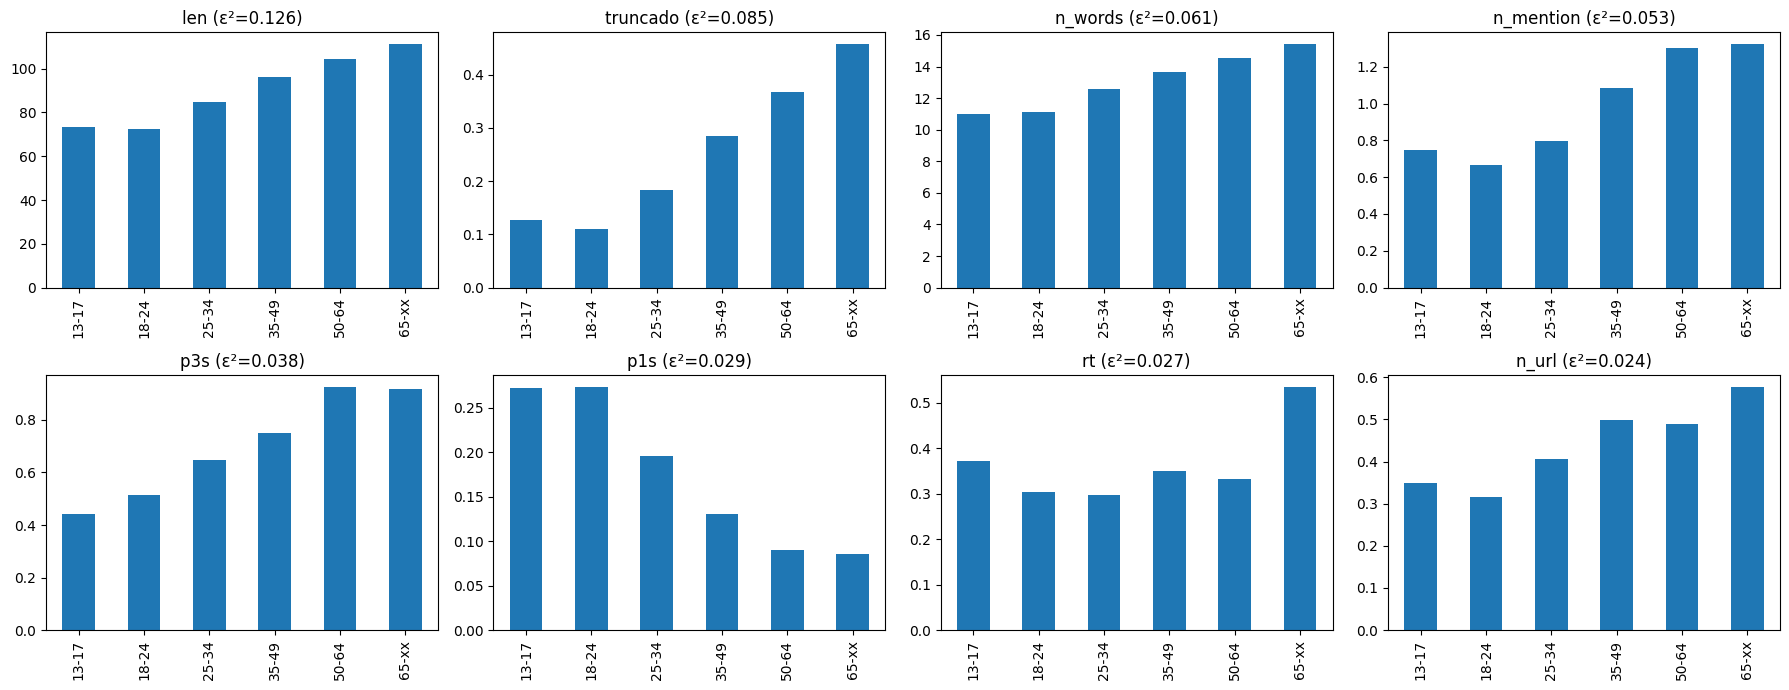

In [10]:
top = eps.sort_values(ascending=False).index[:8]
fig, axes = plt.subplots(2, 4, figsize=(18, 7))
for ax, c in zip(axes.ravel(), top):
    F.groupby('y')[c].mean().reindex(ORDER).plot.bar(ax=ax, title=f'{c} (ε²={eps[c]:.3f})')
    ax.set_xlabel('')
plt.tight_layout(); plt.show()

## 4. ¿A quién retuitean y mencionan? (pureza de cuentas)

In [11]:
def pureza(s): return s.value_counts(normalize=True).iloc[0]
tr['rt_acc'] = tr.text.str.extract(r'^RT @(\w+)')[0].str.lower()
rt = tr.dropna(subset=['rt_acc'])
for k in ORDER:
    print(k, list(rt.loc[rt.age_range==k, 'rt_acc'].value_counts().head(6).index))
acc = rt.groupby('rt_acc')['age_range'].agg(n='size', p=pureza).query('n >= 20')
print('\nCuentas retuiteadas ≥20 veces:', len(acc), '| pureza mediana:', round(acc.p.median(), 2))
men = tr.text.str.findall(r'@(\w+)').apply(lambda x: list({m.lower() for m in x}))
e = tr.assign(men=men).explode('men').dropna(subset=['men'])
m = e.groupby('men')['age_range'].agg(n='size', p=pureza).query('n >= 20')
print('Usuarios mencionados ≥20 veces:', len(m), '| pureza mediana:', round(m.p.median(), 2))

13-17 ['justinbieber', 'juan_da_mc', 'alvaro_stash', 'screamau', 'nashgrier', 'josellopiz']
18-24 ['justinbieber', 'mariobautista_', 'bts_twt', '_elbrayan_', 'cariverplate', 'elcosodelapizza']
25-34 ['ondaplc', 'sin_protocolo', 'elespectador', 'mariacorinaya', 'albertort51', 'fil0s0fia']
35-49 ['barcelonascweb', 'mctobon', 'eltiempo', 'noticiascaracol', 'prensacom', 'alvarouribevel']
50-64 ['erescurioso', 'theleaguemag', 'cabrerizomaria', 'favstar_bot', 'culturizando', 'eltiempo']
65-xx ['elnacionalweb', 'el_cooperante', 'adrianrubalcava', 'la_patilla', 'periodicovzlano', 'jerobledo']

Cuentas retuiteadas ≥20 veces: 337 | pureza mediana: 0.76
Usuarios mencionados ≥20 veces: 1038 | pureza mediana: 0.77


## 5. Vocabulario distintivo por grupo
Log-odds con prior de Dirichlet informativo (Monroe, Colaresi & Quinn, 2008), cada grupo contra el resto. Se excluyen URL y @usuarios.

In [12]:
def clean(s):
    s = s.str.lower().str.replace(r'https?://\S+', ' ', regex=True)
    return s.str.replace(r'@\w+', ' ', regex=True).str.replace(r'^rt\b', ' ', regex=True)
cv = CountVectorizer(token_pattern=r'(?u)#?\b[a-z]{2,}\b', min_df=20)
X = cv.fit_transform(clean(tr.text)); V = np.array(cv.get_feature_names_out())
y = tr.age_range.values
tot = np.asarray(X.sum(0)).ravel(); alpha = tot * 1000 / tot.sum(); A = alpha.sum()
distinctive = {}
for k in ORDER:
    yi = np.asarray(X[y==k].sum(0)).ravel(); yj = tot - yi; ni, nj = yi.sum(), yj.sum()
    d = np.log((yi+alpha)/(ni+A-yi-alpha)) - np.log((yj+alpha)/(nj+A-yj-alpha))
    z = d / np.sqrt(1/(yi+alpha) + 1/(yj+alpha))
    distinctive[k] = V[np.argsort(-z)[:25]]
pd.DataFrame(distinctive)

,13-17,18-24,25-34,35-49,50-64,65-xx
0,me,me,photo,out,la,de
1,te,te,rico,post,de,en
2,follow,yo,pero,disponible,el,del
3,for,quiero,escaleras,diario,del,https
4,lt,mi,#friends,stories,en,more
5,justin,que,#feliz,is,paz,la
6,you,perfil,jajaja,latest,los,venezuela
7,amo,pessoas,sorteo,time,cali,pop
8,bieber,you,maximo,de,farc,maduro
9,please,amo,xbox,macri,santos,#efemerides
